In [1]:
import pandas as pd
import numpy as np
import re
import difflib

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
sns.set_theme(style="whitegrid") 
RANDOM_STATE = 42

RAW_PATH = "goodreads_data.csv"     
CLEAN_PATH = "goodreads_cleaned.csv"

TOP_K_RECS = 10                      
KMEANS_K = 25                        
SVD_COMPONENTS = 100  

In [3]:
df_raw = pd.read_csv(RAW_PATH)
print("Raw shape:", df_raw.shape)
print("Columns:", list(df_raw.columns))

df_raw.head()

Raw shape: (10000, 8)
Columns: ['Unnamed: 0', 'Book', 'Author', 'Description', 'Genres', 'Avg_Rating', 'Num_Ratings', 'URL']


,Unnamed: 0,Book,Author,Description,Genres,Avg_Rating,Num_Ratings,URL
0,0,To Kill a Mockingbird,Harper Lee,The unforgettable novel of a childhood in a sl...,"['Classics', 'Fiction', 'Historical Fiction', ...",4.27,"5,691,311",https://www.goodreads.com/book/show/2657.To_Ki...
1,1,Harry Potter and the Philosopher’s Stone (Harr...,J.K. Rowling,Harry Potter thinks he is an ordinary boy - un...,"['Fantasy', 'Fiction', 'Young Adult', 'Magic',...",4.47,"9,278,135",https://www.goodreads.com/book/show/72193.Harr...
2,2,Pride and Prejudice,Jane Austen,"Since its immediate success in 1813, Pride and...","['Classics', 'Fiction', 'Romance', 'Historical...",4.28,"3,944,155",https://www.goodreads.com/book/show/1885.Pride...
3,3,The Diary of a Young Girl,Anne Frank,Discovered in the attic in which she spent the...,"['Classics', 'Nonfiction', 'History', 'Biograp...",4.18,"3,488,438",https://www.goodreads.com/book/show/48855.The_...
4,4,Animal Farm,George Orwell,Librarian's note: There is an Alternate Cover ...,"['Classics', 'Fiction', 'Dystopia', 'Fantasy',...",3.98,"3,575,172",https://www.goodreads.com/book/show/170448.Ani...


In [4]:
def basic_text_clean(x):
    if pd.isna(x):
        return ""
    x = str(x).strip()
    x = re.sub(r"[\[\]]", "", x)     
    x = re.sub(r"[\"']", "", x) 
    x = re.sub(r"[|;/]+", ",", x)
    x = re.sub(r"\s+", " ", x)
    x = re.sub(r"\s*,\s*", ", ", x) 
    x = re.sub(r"(,\s*)+", ", ", x).strip(" ,") 
    return x

df = df_raw.copy()

df = df.drop(columns=["Unnamed: 0", "URL"], errors="ignore")

required_cols = ["Book", "Author", "Genres", "Description", "Avg_Rating", "Num_Ratings"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}. Please check your CSV headers.")

for col in ["Book", "Author", "Genres", "Description"]:
    df[col] = df[col].apply(basic_text_clean)
    df.loc[df[col].eq(""), col] = np.nan

df.loc[df["Genres"].astype(str).str.strip().eq(""), "Genres"] = np.nan

df = df.dropna(subset=["Book", "Author", "Genres", "Description"]).copy()

df = df.drop_duplicates(subset=["Book", "Author"]).reset_index(drop=True)

df["Avg_Rating"] = pd.to_numeric(df["Avg_Rating"], errors="coerce")
df["Num_Ratings_num"] = pd.to_numeric(
    df["Num_Ratings"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

df = df.dropna(subset=["Avg_Rating", "Num_Ratings_num"]).reset_index(drop=True)

df = df[df["Description"].str.len() >= 30].reset_index(drop=True)

df.to_csv(CLEAN_PATH, index=False)
print("Cleaned shape:", df.shape)
print("Saved cleaned file:", CLEAN_PATH)

df.head()

Cleaned shape: (8873, 7)
Saved cleaned file: goodreads_cleaned.csv


,Book,Author,Description,Genres,Avg_Rating,Num_Ratings,Num_Ratings_num
0,To Kill a Mockingbird,Harper Lee,The unforgettable novel of a childhood in a sl...,"Classics, Fiction, Historical Fiction, School,...",4.27,"5,691,311",5691311
1,Harry Potter and the Philosopher’s Stone (Harr...,J.K. Rowling,Harry Potter thinks he is an ordinary boy - un...,"Fantasy, Fiction, Young Adult, Magic, Children...",4.47,"9,278,135",9278135
2,Pride and Prejudice,Jane Austen,"Since its immediate success in 1813, Pride and...","Classics, Fiction, Romance, Historical Fiction...",4.28,"3,944,155",3944155
3,The Diary of a Young Girl,Anne Frank,Discovered in the attic in which she spent the...,"Classics, Nonfiction, History, Biography, Memo...",4.18,"3,488,438",3488438
4,Animal Farm,George Orwell,Librarians note: There is an Alternate Cover E...,"Classics, Fiction, Dystopia, Fantasy, Politics...",3.98,"3,575,172",3575172


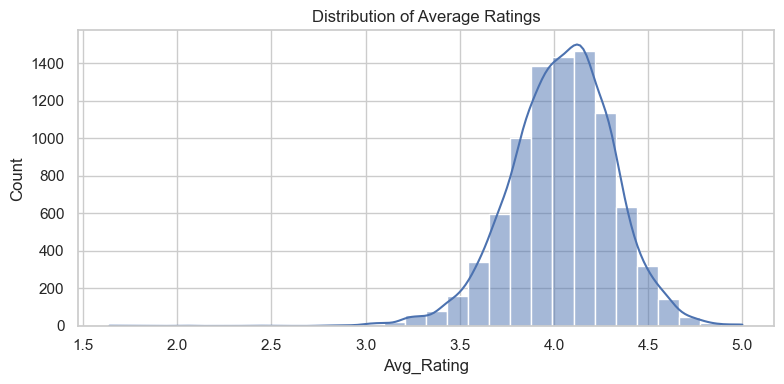

In [5]:
plt.figure(figsize=(8, 4))
sns.histplot(df["Avg_Rating"], bins=30, kde=True)
plt.title("Distribution of Average Ratings")
plt.xlabel("Avg_Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

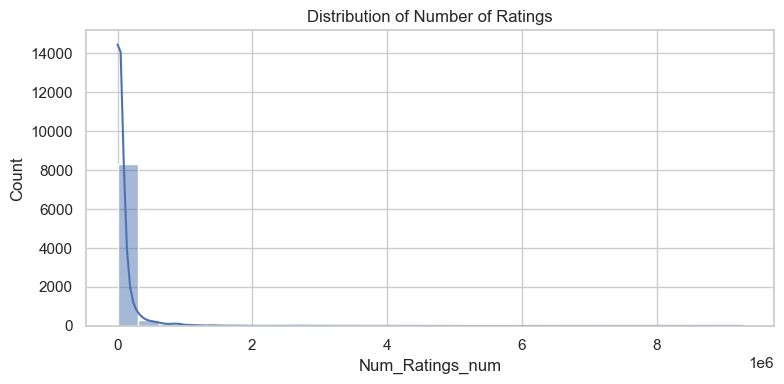

In [6]:
plt.figure(figsize=(8, 4))
sns.histplot(df["Num_Ratings_num"], bins=30, kde=True)
plt.title("Distribution of Number of Ratings")
plt.xlabel("Num_Ratings_num")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

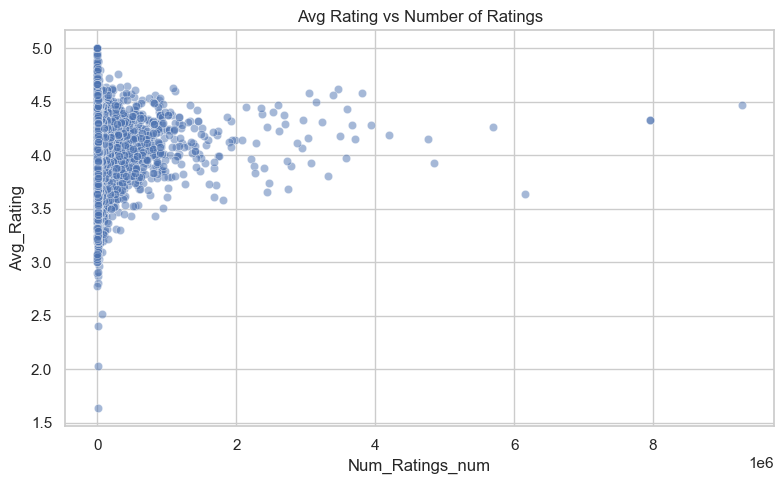

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["Num_Ratings_num"], y=df["Avg_Rating"], alpha=0.5)
plt.title("Avg Rating vs Number of Ratings")
plt.xlabel("Num_Ratings_num")
plt.ylabel("Avg_Rating")
plt.tight_layout()
plt.show()

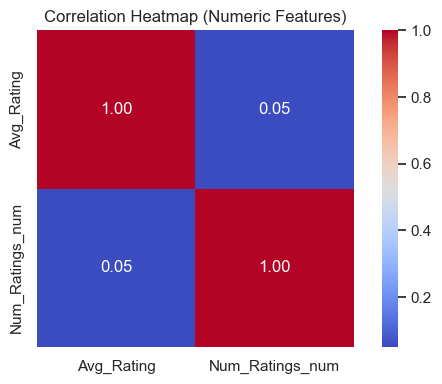

In [8]:
corr = df[["Avg_Rating", "Num_Ratings_num"]].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()


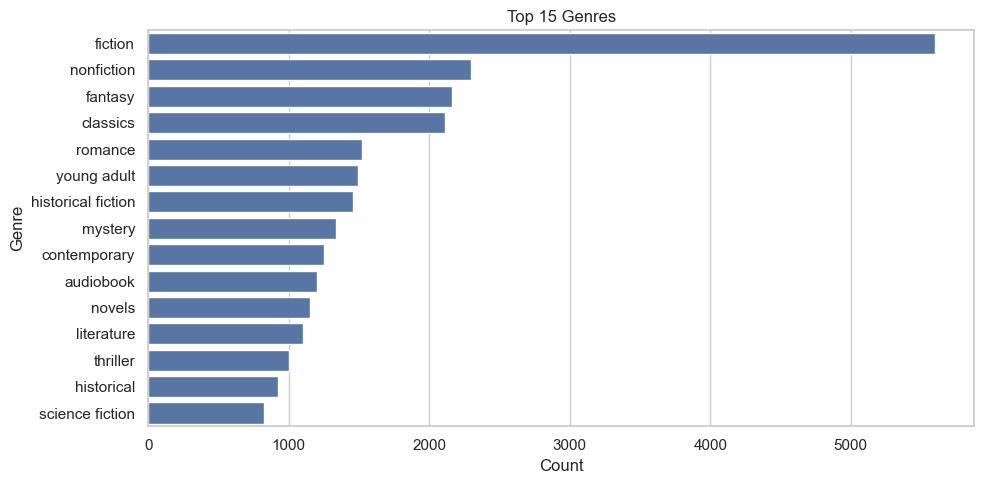

In [9]:
def parse_genres(genres_str: str) -> set:
    if pd.isna(genres_str):
        return set()
    parts = re.split(r"[,\|;/]+", str(genres_str))
    parts = [p.strip().lower() for p in parts if p.strip()]
    return set(parts)

genre_sets = df["Genres"].apply(parse_genres).tolist()

all_genres = []
for s in genre_sets:
    all_genres.extend(list(s))

top = Counter(all_genres).most_common(15)
labels, counts = zip(*top) if top else ([], [])

plt.figure(figsize=(10, 5))
sns.barplot(x=list(counts), y=list(labels))
plt.title("Top 15 Genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

In [10]:
df["combined_text"] = (
    df["Book"].fillna("") + " " +
    df["Author"].fillna("") + " " +
    df["Genres"].fillna("") + " " +
    df["Description"].fillna("")
)

tfidf = TfidfVectorizer(stop_words="english", max_features=50000, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(df["combined_text"])


cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

titles = df["Book"].astype(str).tolist()
title_to_index = {t: i for i, t in enumerate(titles)}

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (8873, 50000)


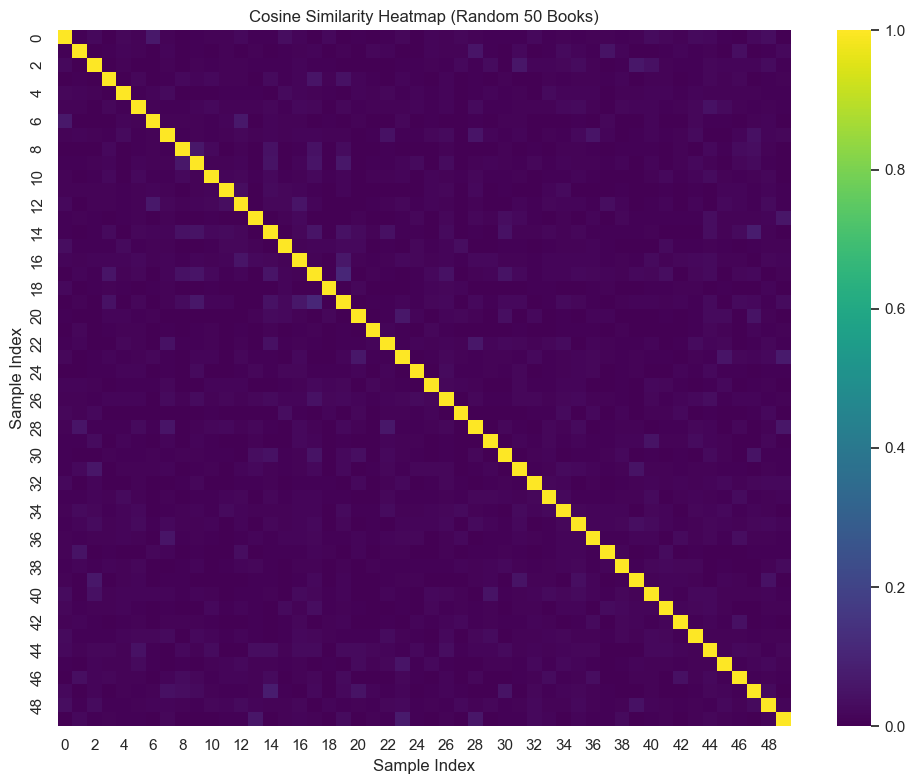

In [11]:
N = 50
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(np.arange(len(df)), size=min(N, len(df)), replace=False)
subset = cosine_sim[np.ix_(sample_idx, sample_idx)]

plt.figure(figsize=(10, 8))
sns.heatmap(subset, cmap="viridis")
plt.title(f"Cosine Similarity Heatmap (Random {len(sample_idx)} Books)")
plt.xlabel("Sample Index")
plt.ylabel("Sample Index")
plt.tight_layout()
plt.show()

In [12]:
all_indices = np.arange(len(df))
train_idx, test_idx = train_test_split(all_indices, test_size=0.2, random_state=RANDOM_STATE)
print("Train size:", len(train_idx), "Test size:", len(test_idx))

Train size: 7098 Test size: 1775


In [13]:
def recommend_content_by_index(book_index: int, top_k: int = 10) -> pd.DataFrame:
    sims = cosine_sim[book_index]
    ranked = np.argsort(sims)[::-1]
    ranked = ranked[ranked != book_index]
    top_idx = ranked[:top_k]

    out = df.loc[top_idx, ["Book", "Author", "Genres", "Avg_Rating", "Num_Ratings_num"]].copy()
    out["Similarity"] = sims[top_idx]
    return out.reset_index(drop=True)


In [14]:
knn = NearestNeighbors(metric="cosine", algorithm="brute")
knn.fit(tfidf_matrix)

def recommend_knn_by_index(book_index: int, top_k: int = 10) -> pd.DataFrame:
    distances, indices = knn.kneighbors(tfidf_matrix[book_index], n_neighbors=top_k + 1)
    indices = indices.flatten()
    distances = distances.flatten()

    mask = indices != book_index
    indices = indices[mask][:top_k]
    distances = distances[mask][:top_k]
    sims = 1 - distances

    out = df.loc[indices, ["Book", "Author", "Genres", "Avg_Rating", "Num_Ratings_num"]].copy()
    out["Similarity"] = sims
    return out.reset_index(drop=True)

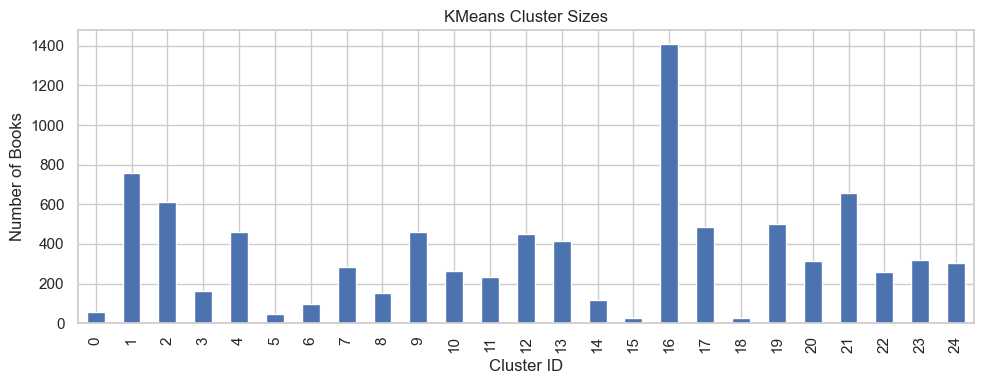

In [15]:
SVD_COMPONENTS = 100
KMEANS_K = 25

svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=RANDOM_STATE)
tfidf_reduced = svd.fit_transform(tfidf_matrix)

kmeans = KMeans(n_clusters=KMEANS_K, random_state=RANDOM_STATE, n_init="auto")
df["cluster"] = kmeans.fit_predict(tfidf_reduced)

# cluster size chart
plt.figure(figsize=(10, 4))
df["cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("KMeans Cluster Sizes")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.show()

In [16]:
def recommend_kmeans_by_index(book_index: int, top_k: int = 10) -> pd.DataFrame:
    cid = df.loc[book_index, "cluster"]
    cluster_inds = df.index[df["cluster"] == cid].to_numpy()

    # fallback if cluster too small
    if len(cluster_inds) <= 1:
        return recommend_content_by_index(book_index, top_k=top_k)

    sims_cluster = cosine_sim[book_index, cluster_inds]
    ranked_local = cluster_inds[np.argsort(sims_cluster)[::-1]]
    ranked_local = ranked_local[ranked_local != book_index]
    top_idx = ranked_local[:top_k]

    out = df.loc[top_idx, ["Book", "Author", "Genres", "Avg_Rating", "Num_Ratings_num", "cluster"]].copy()
    out["Similarity"] = cosine_sim[book_index, top_idx]
    return out.reset_index(drop=True)

In [17]:
def best_title_match(user_title: str, cutoff: float = 0.6):
    user_title = str(user_title).strip()
    if not user_title:
        return None, []
    if user_title in title_to_index:
        return user_title, [user_title]
    matches = difflib.get_close_matches(user_title, titles, n=5, cutoff=cutoff)
    best = matches[0] if matches else None
    return best, matches

In [18]:
def recommend_by_title_content(user_title: str, top_k: int = 10):
    picked, suggestions = best_title_match(user_title)
    if not picked:
        raise ValueError("Title not found.")
    print(f"Query used: {picked}")
    if picked != user_title and len(suggestions) > 1:
        print("Close matches:", suggestions[:5])
    return recommend_content_by_index(title_to_index[picked], top_k=top_k)

In [19]:
def recommend_by_title_knn(user_title: str, top_k: int = 10):
    picked, suggestions = best_title_match(user_title)
    if not picked:
        raise ValueError("Title not found.")
    print(f"Query used: {picked}")
    if picked != user_title and len(suggestions) > 1:
        print("Close matches:", suggestions[:5])
    return recommend_knn_by_index(title_to_index[picked], top_k=top_k)

In [20]:
def recommend_by_title_kmeans(user_title: str, top_k: int = 10):
    picked, suggestions = best_title_match(user_title)
    if not picked:
        raise ValueError("Title not found.")
    print(f"Query used: {picked}")
    if picked != user_title and len(suggestions) > 1:
        print("Close matches:", suggestions[:5])
    return recommend_kmeans_by_index(title_to_index[picked], top_k=top_k)


In [21]:
def run_demo(top_k: int = 10):
    print("\n Demo: type 'exit' to stop.")
    while True:
        t = input("Enter a book title: ").strip()
        if t.lower() in ["exit", "quit", "q"]:
            break
        try:
            print("\n--- Content-Based ---")
            display(recommend_by_title_content(t, top_k=top_k))
            print("\n--- KNN ---")
            display(recommend_by_title_knn(t, top_k=top_k))
            print("\n--- KMeans ---")
            display(recommend_by_title_kmeans(t, top_k=top_k))
        except Exception as e:
            print("Error:", e)


In [22]:
def relevant_set_for_query(q_index: int) -> set:
    """All items that share at least one genre with query (excluding itself)."""
    qg = genre_sets[q_index]
    if not qg:
        return set()
    rel = set()
    for i in range(len(df)):
        if i == q_index:
            continue
        if len(qg.intersection(genre_sets[i])) > 0:
            rel.add(i)
    return rel

In [23]:
def get_recs_indices(method: str, q: int, k: int = 10) -> np.ndarray:
    method = method.lower().strip()

    if method == "content":
        sims = cosine_sim[q]
        ranked = np.argsort(sims)[::-1]
        ranked = ranked[ranked != q]
        return ranked[:k]

    if method == "knn":
        dists, inds = knn.kneighbors(tfidf_matrix[q], n_neighbors=k + 1)
        inds = inds.flatten()
        inds = inds[inds != q][:k]
        return inds

    if method in ["kmeans", "k-means"]:
        cid = df.loc[q, "cluster"]
        cluster_inds = df.index[df["cluster"] == cid].to_numpy()

        if len(cluster_inds) <= 1:
            sims = cosine_sim[q]
            ranked = np.argsort(sims)[::-1]
            ranked = ranked[ranked != q]
            return ranked[:k]

        sims_cluster = cosine_sim[q, cluster_inds]
        ranked_local = cluster_inds[np.argsort(sims_cluster)[::-1]]
        ranked_local = ranked_local[ranked_local != q]
        return ranked_local[:k]

    raise ValueError("method must be content, knn, or kmeans")

In [24]:
def recall_at_k(recs: np.ndarray, relevant: set, k: int) -> float:
    if len(relevant) == 0:
        return np.nan
    recs_k = recs[:k]
    hits = sum(1 for r in recs_k if r in relevant)
    return hits / len(relevant)

In [25]:
def average_precision_at_k(recs: np.ndarray, relevant: set, k: int) -> float:
    """AP@K for one query."""
    if len(relevant) == 0:
        return np.nan

    score = 0.0
    hits = 0
    for i, r in enumerate(recs[:k], start=1):
        if r in relevant:
            hits += 1
            score += hits / i
    return score / min(len(relevant), k)

In [26]:
def mean_average_precision_at_k(method: str, k: int = 10, queries=None) -> float:
    if queries is None:
        queries = test_idx

    scores = []
    for q in queries:
        relevant = relevant_set_for_query(q)
        recs = get_recs_indices(method, q, k=k)
        ap = average_precision_at_k(recs, relevant, k)
        if not np.isnan(ap):
            scores.append(ap)

    return np.mean(scores) if scores else np.nan


In [27]:
def ndcg_at_k(recs: np.ndarray, relevant: set, k: int) -> float:
    """Binary relevance NDCG@K."""
    if len(relevant) == 0:
        return np.nan

    def dcg(rs):
        return sum((1.0 / np.log2(i + 1)) for i, rel in enumerate(rs, start=1) if rel == 1)

    rels = [1 if r in relevant else 0 for r in recs[:k]]
    dcg_val = dcg(rels)

    ideal_ones = [1] * min(len(relevant), k)
    idcg_val = dcg(ideal_ones)

    return dcg_val / idcg_val if idcg_val > 0 else np.nan

In [28]:
def precision_at_k(recs: np.ndarray, relevant: set, k: int) -> float:
    """Precision@K for one query."""
    if len(relevant) == 0:
        return np.nan
    hits = sum(1 for r in recs[:k] if r in relevant)
    return hits / k


In [29]:
def evaluate_all_metrics(method: str, k: int = 10, queries=None) -> dict:
    """
    Returns mean Precision@K, Recall@K, MAP@K, NDCG@K
    over all test queries.
    """
    if queries is None:
        queries = test_idx

    p_list, r_list, ap_list, ndcg_list = [], [], [], []

    for q in queries:
        relevant = relevant_set_for_query(q)
        if len(relevant) == 0:
            continue

        recs = get_recs_indices(method, q, k=k)

        p = precision_at_k(recs, relevant, k)
        r = recall_at_k(recs, relevant, k)
        ap = average_precision_at_k(recs, relevant, k)
        nd = ndcg_at_k(recs, relevant, k)

        if not np.isnan(p): p_list.append(p)
        if not np.isnan(r): r_list.append(r)
        if not np.isnan(ap): ap_list.append(ap)
        if not np.isnan(nd): ndcg_list.append(nd)

    return {
        f"Precision@{k}": float(np.mean(p_list)) if p_list else np.nan,
        f"Recall@{k}": float(np.mean(r_list)) if r_list else np.nan,
        f"MAP@{k}": float(np.mean(ap_list)) if ap_list else np.nan,
        f"NDCG@{k}": float(np.mean(ndcg_list)) if ndcg_list else np.nan,
    }

In [30]:
K = 10 

results_content = evaluate_all_metrics("content", k=K)
results_knn = evaluate_all_metrics("knn", k=K)
results_kmeans = evaluate_all_metrics("kmeans", k=K)

comparison_metrics = pd.DataFrame([
    {"Algorithm": "Content-Based (TF-IDF + Cosine)", **results_content},
    {"Algorithm": "KNN (NearestNeighbors)", **results_knn},
    {"Algorithm": "K-Means (Cluster + Similarity)", **results_kmeans},
])

print(
    f"\n=== COMPARISON (Precision@{K}, Recall@{K}, MAP@{K}, NDCG@{K}) "
    f"— Higher values indicate better performance ==="
)

comparison_metrics




=== COMPARISON (Precision@10, Recall@10, MAP@10, NDCG@10) — Higher values indicate better performance ===


,Algorithm,Precision@10,Recall@10,MAP@10,NDCG@10
0,Content-Based (TF-IDF + Cosine),0.869521,0.002475,0.813303,0.874754
1,KNN (NearestNeighbors),0.869521,0.002475,0.813303,0.874754
2,K-Means (Cluster + Similarity),0.937296,0.002549,0.915605,0.937958


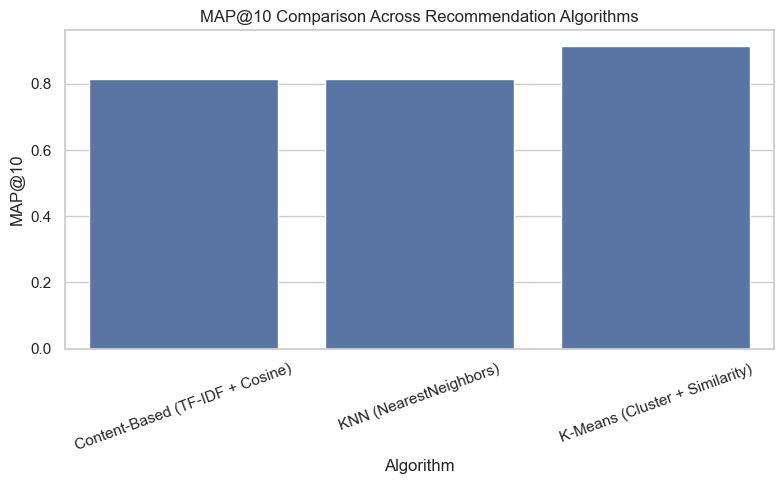

In [31]:
metrics_df = comparison_metrics.copy()
metrics_df


plt.figure(figsize=(8, 5))
sns.barplot(
    data=metrics_df,
    x="Algorithm",
    y="MAP@10"
)

plt.title("MAP@10 Comparison Across Recommendation Algorithms")
plt.ylabel("MAP@10")
plt.xlabel("Algorithm")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


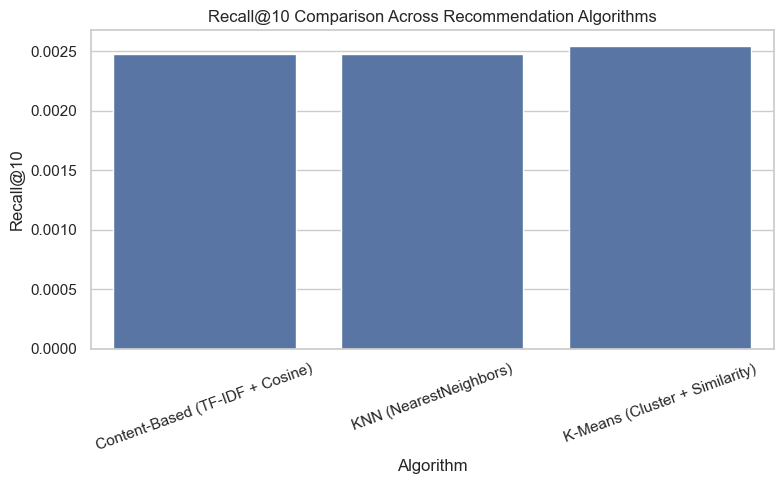

In [32]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=metrics_df,
    x="Algorithm",
    y="Recall@10"
)

plt.title("Recall@10 Comparison Across Recommendation Algorithms")
plt.ylabel("Recall@10")
plt.xlabel("Algorithm")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


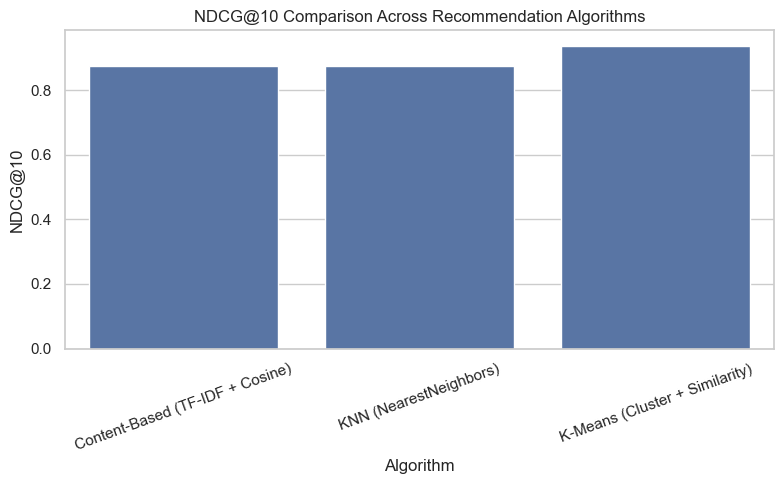

In [33]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=metrics_df,
    x="Algorithm",
    y="NDCG@10"
)

plt.title("NDCG@10 Comparison Across Recommendation Algorithms")
plt.ylabel("NDCG@10")
plt.xlabel("Algorithm")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


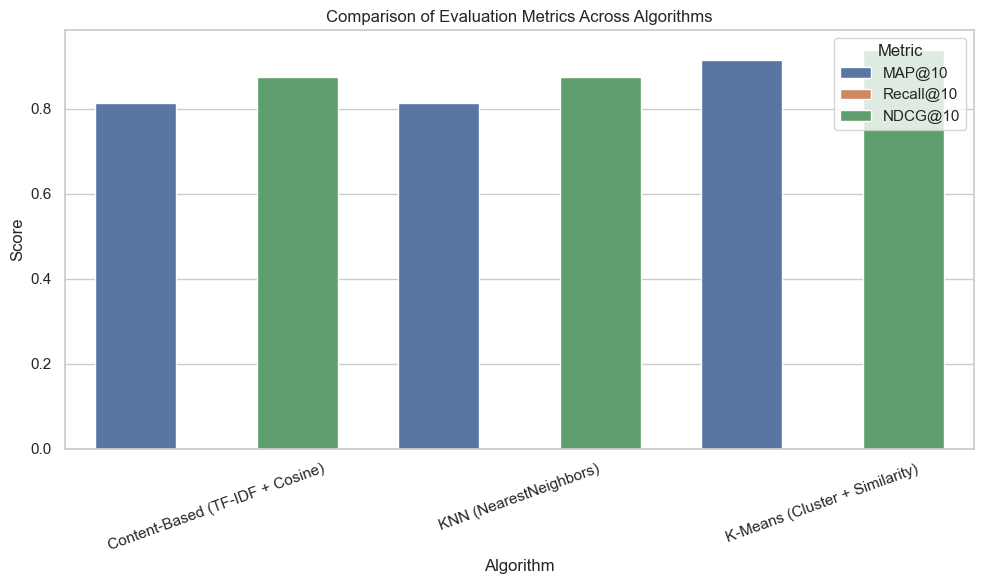

In [34]:
metrics_long = metrics_df.melt(
    id_vars="Algorithm",
    value_vars=["MAP@10", "Recall@10", "NDCG@10"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=metrics_long,
    x="Algorithm",
    y="Score",
    hue="Metric"
)

plt.title("Comparison of Evaluation Metrics Across Algorithms")
plt.ylabel("Score")
plt.xlabel("Algorithm")
plt.xticks(rotation=20)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


In [35]:
def build_confusion_data(method: str, k: int = 10, num_queries: int = 120, pool_size: int = 200, seed: int = 42):
   
    rng = np.random.default_rng(seed)
    queries = test_idx

    if len(queries) > num_queries:
        queries = rng.choice(queries, size=num_queries, replace=False)

    all_idx = np.arange(len(df))

    y_true_all, y_pred_all = [], []

    for q in queries:
        qg = genre_sets[q]
        if not qg:
            continue

        pool_size_eff = min(pool_size, len(all_idx) - 1)
        candidates = rng.choice(all_idx[all_idx != q], size=pool_size_eff, replace=False)

        true_labels = [1 if len(qg.intersection(genre_sets[c])) > 0 else 0 for c in candidates]

        recs = set(get_recs_indices(method, q, k=k))
        pred_labels = [1 if c in recs else 0 for c in candidates]

        y_true_all.extend(true_labels)
        y_pred_all.extend(pred_labels)

    return np.array(y_true_all), np.array(y_pred_all)


<Figure size 500x400 with 0 Axes>

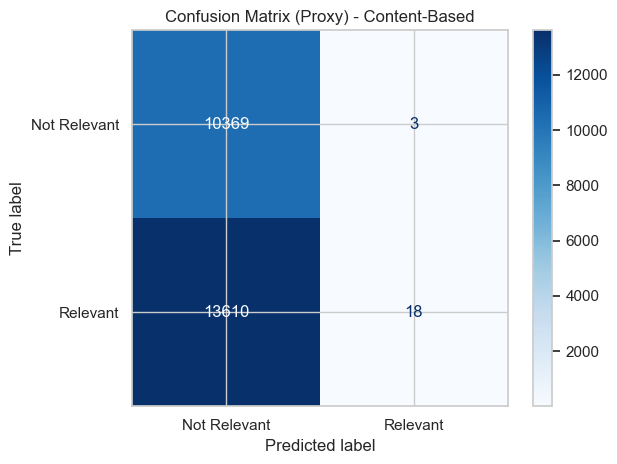

<Figure size 500x400 with 0 Axes>

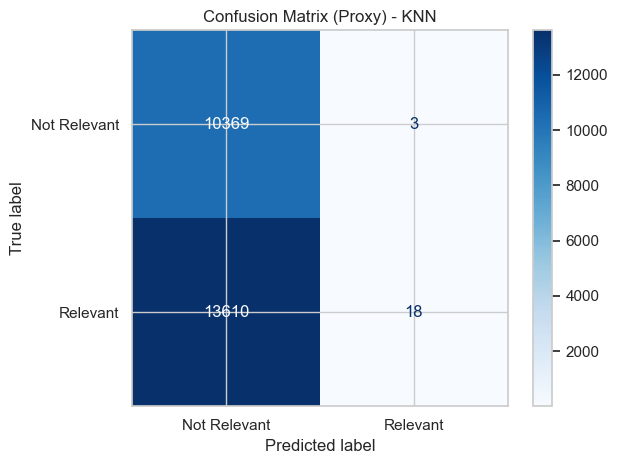

<Figure size 500x400 with 0 Axes>

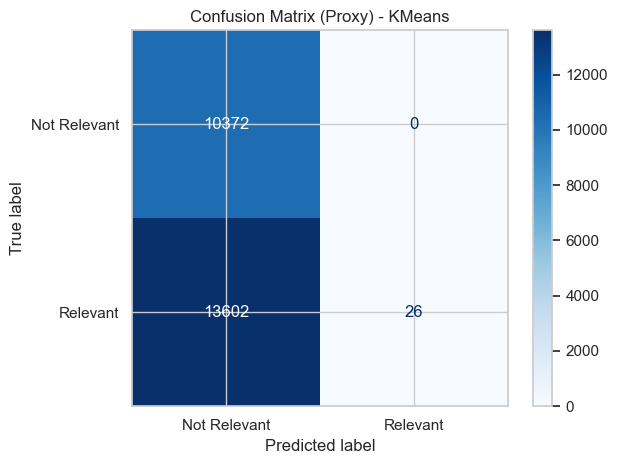

In [37]:
def plot_confusion(title: str, y_true: np.ndarray, y_pred: np.ndarray):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Relevant", "Relevant"])
    plt.figure(figsize=(5, 4))
    disp.plot(values_format="d", cmap="Blues")
    plt.title(title)
    plt.tight_layout()
    plt.show()

K_EVAL = 10

y_true_c, y_pred_c = build_confusion_data("content", k=K_EVAL, seed=RANDOM_STATE)
plot_confusion("Confusion Matrix (Proxy) - Content-Based", y_true_c, y_pred_c)

y_true_k, y_pred_k = build_confusion_data("knn", k=K_EVAL, seed=RANDOM_STATE)
plot_confusion("Confusion Matrix (Proxy) - KNN", y_true_k, y_pred_k)

y_true_m, y_pred_m = build_confusion_data("kmeans", k=K_EVAL, seed=RANDOM_STATE)
plot_confusion("Confusion Matrix (Proxy) - KMeans", y_true_m, y_pred_m)

In [39]:
display(
    recommend_by_title_content(
        "Harry Potter",
        top_k=10
    )
)


Query used: Earthly Powers
Close matches: ['Earthly Powers', 'Earthly Powers', 'Dark Matter']


,Book,Author,Genres,Avg_Rating,Num_Ratings_num,Similarity
0,A Clockwork Orange,Anthony Burgess,"Classics, Fiction, Science Fiction, Dystopia, ...",4.00,681585,0.280424
1,The Wanting Seed,Anthony Burgess,"Fiction, Science Fiction, Dystopia, Classics, ...",3.74,6063,0.164707
2,"Dogfight, A Love Story",Matt Burgess,"Fiction, Literary Fiction",3.56,514,0.154292
3,Earthly Powers,David Anderson,"Thriller, Mystery",4.59,80,0.154135
4,Wonderful Life: The Burgess Shale and the Natu...,Stephen Jay Gould,"Science, Nonfiction, Biology, Evolution, Histo...",4.14,9638,0.124692
5,Feed,M.T. Anderson,"Young Adult, Science Fiction, Dystopia, Fictio...",3.55,61960,0.088098
6,"The Gormenghast Novels (Gormenghast, #1-3)",Mervyn Peake,"Fantasy, Fiction, Classics, Gothic, Horror, No...",4.01,9105,0.087154
7,Catch-22,Joseph Heller,"Classics, Fiction, Historical Fiction, War, Hu...",3.99,804276,0.084068
8,In Dubious Battle,John Steinbeck,"Fiction, Classics, Literature, Historical Fict...",3.91,13573,0.077425
9,"Autumn (Seasonal Quartet, #1)",Ali Smith,"Fiction, Contemporary, Literary Fiction, Novel...",3.69,69165,0.072914


In [41]:
display(
    recommend_by_title_knn(
        "Harry Potter",
        top_k=10
    )
)


Query used: Earthly Powers
Close matches: ['Earthly Powers', 'Earthly Powers', 'Dark Matter']


,Book,Author,Genres,Avg_Rating,Num_Ratings_num,Similarity
0,A Clockwork Orange,Anthony Burgess,"Classics, Fiction, Science Fiction, Dystopia, ...",4.00,681585,0.280424
1,The Wanting Seed,Anthony Burgess,"Fiction, Science Fiction, Dystopia, Classics, ...",3.74,6063,0.164707
2,"Dogfight, A Love Story",Matt Burgess,"Fiction, Literary Fiction",3.56,514,0.154292
3,Earthly Powers,David Anderson,"Thriller, Mystery",4.59,80,0.154135
4,Wonderful Life: The Burgess Shale and the Natu...,Stephen Jay Gould,"Science, Nonfiction, Biology, Evolution, Histo...",4.14,9638,0.124692
5,Feed,M.T. Anderson,"Young Adult, Science Fiction, Dystopia, Fictio...",3.55,61960,0.088098
6,"The Gormenghast Novels (Gormenghast, #1-3)",Mervyn Peake,"Fantasy, Fiction, Classics, Gothic, Horror, No...",4.01,9105,0.087154
7,Catch-22,Joseph Heller,"Classics, Fiction, Historical Fiction, War, Hu...",3.99,804276,0.084068
8,In Dubious Battle,John Steinbeck,"Fiction, Classics, Literature, Historical Fict...",3.91,13573,0.077425
9,"Autumn (Seasonal Quartet, #1)",Ali Smith,"Fiction, Contemporary, Literary Fiction, Novel...",3.69,69165,0.072914


In [43]:
display(
    recommend_by_title_kmeans(
        "Harry Potter",
        top_k=10
    )
)


Query used: Earthly Powers
Close matches: ['Earthly Powers', 'Earthly Powers', 'Dark Matter']


,Book,Author,Genres,Avg_Rating,Num_Ratings_num,cluster,Similarity
0,A Clockwork Orange,Anthony Burgess,"Classics, Fiction, Science Fiction, Dystopia, ...",4.00,681585,17,0.280424
1,The Wanting Seed,Anthony Burgess,"Fiction, Science Fiction, Dystopia, Classics, ...",3.74,6063,17,0.164707
2,"The Gormenghast Novels (Gormenghast, #1-3)",Mervyn Peake,"Fantasy, Fiction, Classics, Gothic, Horror, No...",4.01,9105,17,0.087154
3,Catch-22,Joseph Heller,"Classics, Fiction, Historical Fiction, War, Hu...",3.99,804276,17,0.084068
4,"Phineas Finn (Palliser, #2)",Anthony Trollope,"Classics, Fiction, Victorian, Literature, 19th...",3.98,6928,17,0.071507
5,The Moon and Sixpence,W. Somerset Maugham,"Fiction, Classics, Art, Literature, Historical...",4.13,22726,17,0.069487
6,Of Human Bondage,W. Somerset Maugham,"Classics, Fiction, Literature, Novels, British...",4.13,54824,17,0.063109
7,A Handful of Dust,Evelyn Waugh,"Fiction, Classics, Literature, Novels, British...",3.90,25336,17,0.062805
8,Modern Classics Unconditional Surrender,Evelyn Waugh,"Fiction, Classics, War, Historical Fiction, Li...",4.05,1231,17,0.057963
9,The Dark Diamonds,Mór Jókai,"Classics, Fiction, Hungarian Literature, Histo...",4.15,288,17,0.057066


In [45]:
run_demo(top_k=10)


 Demo: type 'exit' to stop.


Enter a book title:  Harry Potter



--- Content-Based ---
Query used: Earthly Powers
Close matches: ['Earthly Powers', 'Earthly Powers', 'Dark Matter']


,Book,Author,Genres,Avg_Rating,Num_Ratings_num,Similarity
0,A Clockwork Orange,Anthony Burgess,"Classics, Fiction, Science Fiction, Dystopia, ...",4.00,681585,0.280424
1,The Wanting Seed,Anthony Burgess,"Fiction, Science Fiction, Dystopia, Classics, ...",3.74,6063,0.164707
2,"Dogfight, A Love Story",Matt Burgess,"Fiction, Literary Fiction",3.56,514,0.154292
3,Earthly Powers,David Anderson,"Thriller, Mystery",4.59,80,0.154135
4,Wonderful Life: The Burgess Shale and the Natu...,Stephen Jay Gould,"Science, Nonfiction, Biology, Evolution, Histo...",4.14,9638,0.124692
5,Feed,M.T. Anderson,"Young Adult, Science Fiction, Dystopia, Fictio...",3.55,61960,0.088098
6,"The Gormenghast Novels (Gormenghast, #1-3)",Mervyn Peake,"Fantasy, Fiction, Classics, Gothic, Horror, No...",4.01,9105,0.087154
7,Catch-22,Joseph Heller,"Classics, Fiction, Historical Fiction, War, Hu...",3.99,804276,0.084068
8,In Dubious Battle,John Steinbeck,"Fiction, Classics, Literature, Historical Fict...",3.91,13573,0.077425
9,"Autumn (Seasonal Quartet, #1)",Ali Smith,"Fiction, Contemporary, Literary Fiction, Novel...",3.69,69165,0.072914



--- KNN ---
Query used: Earthly Powers
Close matches: ['Earthly Powers', 'Earthly Powers', 'Dark Matter']


,Book,Author,Genres,Avg_Rating,Num_Ratings_num,Similarity
0,A Clockwork Orange,Anthony Burgess,"Classics, Fiction, Science Fiction, Dystopia, ...",4.00,681585,0.280424
1,The Wanting Seed,Anthony Burgess,"Fiction, Science Fiction, Dystopia, Classics, ...",3.74,6063,0.164707
2,"Dogfight, A Love Story",Matt Burgess,"Fiction, Literary Fiction",3.56,514,0.154292
3,Earthly Powers,David Anderson,"Thriller, Mystery",4.59,80,0.154135
4,Wonderful Life: The Burgess Shale and the Natu...,Stephen Jay Gould,"Science, Nonfiction, Biology, Evolution, Histo...",4.14,9638,0.124692
5,Feed,M.T. Anderson,"Young Adult, Science Fiction, Dystopia, Fictio...",3.55,61960,0.088098
6,"The Gormenghast Novels (Gormenghast, #1-3)",Mervyn Peake,"Fantasy, Fiction, Classics, Gothic, Horror, No...",4.01,9105,0.087154
7,Catch-22,Joseph Heller,"Classics, Fiction, Historical Fiction, War, Hu...",3.99,804276,0.084068
8,In Dubious Battle,John Steinbeck,"Fiction, Classics, Literature, Historical Fict...",3.91,13573,0.077425
9,"Autumn (Seasonal Quartet, #1)",Ali Smith,"Fiction, Contemporary, Literary Fiction, Novel...",3.69,69165,0.072914



--- KMeans ---
Query used: Earthly Powers
Close matches: ['Earthly Powers', 'Earthly Powers', 'Dark Matter']


,Book,Author,Genres,Avg_Rating,Num_Ratings_num,cluster,Similarity
0,A Clockwork Orange,Anthony Burgess,"Classics, Fiction, Science Fiction, Dystopia, ...",4.00,681585,17,0.280424
1,The Wanting Seed,Anthony Burgess,"Fiction, Science Fiction, Dystopia, Classics, ...",3.74,6063,17,0.164707
2,"The Gormenghast Novels (Gormenghast, #1-3)",Mervyn Peake,"Fantasy, Fiction, Classics, Gothic, Horror, No...",4.01,9105,17,0.087154
3,Catch-22,Joseph Heller,"Classics, Fiction, Historical Fiction, War, Hu...",3.99,804276,17,0.084068
4,"Phineas Finn (Palliser, #2)",Anthony Trollope,"Classics, Fiction, Victorian, Literature, 19th...",3.98,6928,17,0.071507
5,The Moon and Sixpence,W. Somerset Maugham,"Fiction, Classics, Art, Literature, Historical...",4.13,22726,17,0.069487
6,Of Human Bondage,W. Somerset Maugham,"Classics, Fiction, Literature, Novels, British...",4.13,54824,17,0.063109
7,A Handful of Dust,Evelyn Waugh,"Fiction, Classics, Literature, Novels, British...",3.90,25336,17,0.062805
8,Modern Classics Unconditional Surrender,Evelyn Waugh,"Fiction, Classics, War, Historical Fiction, Li...",4.05,1231,17,0.057963
9,The Dark Diamonds,Mór Jókai,"Classics, Fiction, Hungarian Literature, Histo...",4.15,288,17,0.057066


Enter a book title:  Exit
